In [171]:
import numpy as np
import matplotlib.pyplot as plt

# Part 1:

In [172]:
P = np.array([
    [0.9915, 0.005,  0.0025, 0,     0.001],
    [0,      0.986,  0.005,  0.004, 0.005],
    [0,      0,      0.992,  0.003, 0.005],
    [0,      0,      0,      0.991, 0.009],
    [0,      0,      0,      0,     1    ]
])
state_names = ["Healthy", "Local recurrence", "Distant metastasis",
               "Local rec. + distant met.", "Dead"]

## Task 1:

In [173]:
np.random.seed(42)
N = 1000
lifetimes = np.zeros(N, dtype=int)
had_local_recurrence = np.zeros(N, dtype=bool)

for i in range(N):
    state = 0
    t = 0
    while state != 4:
        state = np.random.choice(5, p=P[state])
        t += 1
        if state == 1 or state == 3:  # local recurrence (with or without distant met.)
            had_local_recurrence[i] = True
    lifetimes[i] = t

print(f"Mean lifetime:   {lifetimes.mean():.1f} months  ({lifetimes.mean()/12:.1f} years)")
print(f"Median lifetime: {np.median(lifetimes):.1f} months  ({np.median(lifetimes)/12:.1f} years)")
print(f"Proportion with local recurrence: {had_local_recurrence.mean():.4f}  "
      f"({had_local_recurrence.sum()} / {N})")

Mean lifetime:   265.0 months  (22.1 years)
Median lifetime: 224.0 months  (18.7 years)
Proportion with local recurrence: 0.7120  (712 / 1000)


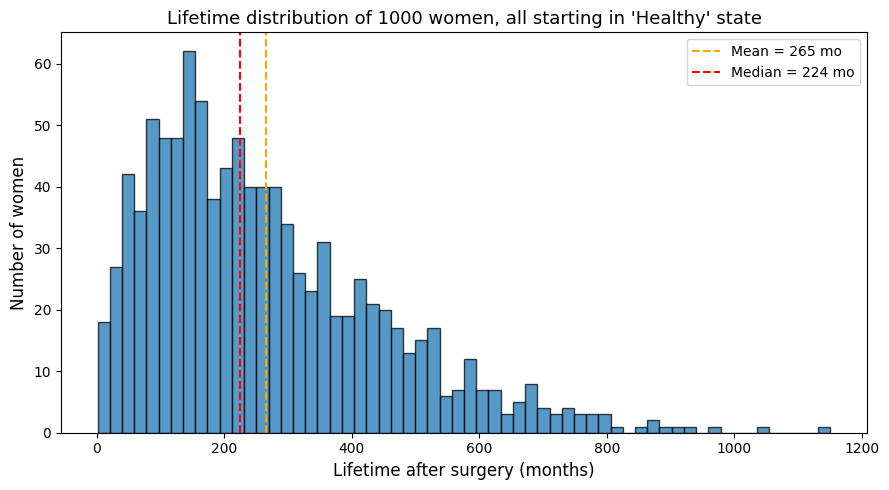

In [174]:
# Histogram of lifetime distribution
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(lifetimes, bins=60, edgecolor='black', alpha=0.75)
ax.set_xlabel("Lifetime after surgery (months)", fontsize=12)
ax.set_ylabel("Number of women", fontsize=12)
ax.set_title("Lifetime distribution of 1000 women, all starting in 'Healthy' state", fontsize=13)
ax.axvline(lifetimes.mean(), color = "orange", linestyle='--', label=f"Mean = {lifetimes.mean():.0f} mo")
ax.axvline(np.median(lifetimes), color = "red", linestyle='--', label=f"Median = {np.median(lifetimes):.0f} mo")
ax.legend()
plt.tight_layout()
plt.show()

## Task 2:

In [175]:
from scipy import stats

t_check = 120
p0 = np.array([1.0, 0, 0, 0, 0])
p_analytical_120 = p0 @ np.linalg.matrix_power(P, t_check)

np.random.seed(42)
states_at_120 = np.zeros(N, dtype=int)
for i in range(N):
    state = 0
    for _ in range(t_check):
        if state == 4:
            break
        state = np.random.choice(5, p=P[state])
    states_at_120[i] = state

observed = np.array([(states_at_120 == s).sum() for s in range(5)])
expected = p_analytical_120 * N

print("State distribution at t = 120 months")
print(f"{'State':<28} {'Expected':>10} {'Observed':>10}")
print("-" * 52)
for s in range(5):
    print(f"{state_names[s]:<28} {expected[s]:>10.2f} {observed[s]:>10d}")

# Merge bins with expected < 5
merged_obs, merged_exp = [], []
acc_o, acc_e = 0, 0
for o, e in zip(observed, expected):
    acc_o += o; acc_e += e
    if acc_e >= 5:
        merged_obs.append(acc_o); merged_exp.append(acc_e)
        acc_o, acc_e = 0, 0
if acc_e > 0:
    merged_obs[-1] += acc_o; merged_exp[-1] += acc_e

merged_obs = np.array(merged_obs)
merged_exp = np.array(merged_exp)
chi2_stat, p_value = stats.chisquare(merged_obs, merged_exp)
dof = len(merged_obs) - 1
print(f"\nChi-squared test (bins used: {len(merged_obs)}, df = {dof})")
print(f"\nChi^2 stat = {chi2_stat:.4f},  p-value = {p_value:.4f}")
if p_value > 0.05:
    print("Fail to reject H0: simulated distribution matches analytical.")
else:
    print("Reject H0 at alpha = 0.05.")

State distribution at t = 120 months
State                          Expected   Observed
----------------------------------------------------
Healthy                          359.03        362
Local recurrence                 158.96        157
Distant metastasis               166.09        186
Local rec. + distant met.         67.74         69
Dead                             248.19        226

Chi-squared test (bins used: 5, df = 4)

Chi^2 stat = 4.4434,  p-value = 0.3493
Fail to reject H0: simulated distribution matches analytical.


## Task 3:

In [176]:
Ps = P[:4, :4]
ps = P[:4, 4]
pi = np.array([1.0, 0.0, 0.0, 0.0])

I4 = np.eye(4)
E_T = pi @ np.linalg.inv(I4 - Ps) @ np.ones(4)
print(f"Theoretical mean lifetime : {E_T:.2f} months  ({E_T/12:.2f} years)")
print(f"Simulated mean lifetime   : {lifetimes.mean():.2f} months  ({lifetimes.mean()/12:.2f} years)\n")

max_k = int(lifetimes.max())
pmf = np.zeros(max_k + 1)
v = pi.copy()
for k in range(1, max_k + 1):
    pmf[k] = v @ ps
    v = v @ Ps

cdf_theoretical = np.cumsum(pmf)
n_bins = 20
bin_edges = [0]
for q in np.linspace(0, 1, n_bins + 1)[1:-1]:
    edge = int(np.searchsorted(cdf_theoretical, q, side='right'))
    bin_edges.append(edge)
bin_edges.append(max_k + 1)
bin_edges = sorted(set(bin_edges))

obs_counts, exp_counts = [], []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    obs_counts.append(int(np.sum((lifetimes >= lo) & (lifetimes < hi))))
    exp_counts.append(float(pmf[lo:hi].sum() * N))

obs_arr = np.array(obs_counts)
exp_arr = np.array(exp_counts)
mask = exp_arr >= 5

exp_norm = exp_arr[mask] * obs_arr[mask].sum() / exp_arr[mask].sum()
chi2_life, p_life = stats.chisquare(obs_arr[mask], exp_norm)
dof_life = mask.sum() - 1
print(f"Chi-squared test empirical vs. phase-type lifetime distribution")
print(f"bins used: {mask.sum()},  df = {dof_life}")
print(f"Chi^2 = {chi2_life:.4f},  p-value = {p_life:.4f}")
if p_life > 0.05:
    print("Fail to reject H0: lifetime distribution matches phase-type.")
else:
    print("Reject H0 at alpha = 0.05.")

Theoretical mean lifetime : 262.37 months  (21.86 years)
Simulated mean lifetime   : 265.04 months  (22.09 years)

Chi-squared test empirical vs. phase-type lifetime distribution
bins used: 20,  df = 19
Chi^2 = 14.0020,  p-value = 0.7836
Fail to reject H0: lifetime distribution matches phase-type.


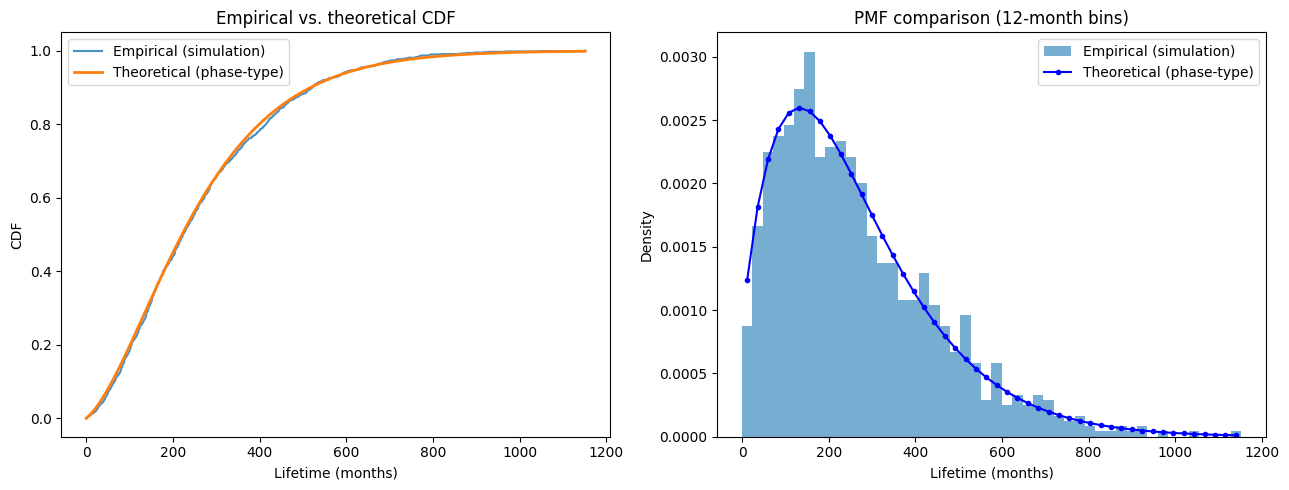

In [177]:
empirical_cdf = np.array([(lifetimes <= k).mean() for k in range(max_k + 1)])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(empirical_cdf, lw=1.5, alpha=0.8, label='Empirical (simulation)')
ax.plot(cdf_theoretical, lw=2, label='Theoretical (phase-type)')
ax.set_xlabel("Lifetime (months)")
ax.set_ylabel("CDF")
ax.set_title("Empirical vs. theoretical CDF")
ax.legend()

ax2 = axes[1]
bin_width = 24
bins = np.arange(0, max_k + bin_width, bin_width)
ax2.hist(lifetimes, bins=bins, density=True, alpha=0.6, label='Empirical (simulation)')
mid = (bins[:-1] + bins[1:]) / 2
theo_density = np.array([pmf[int(lo):int(hi)].sum() / bin_width
                          for lo, hi in zip(bins[:-1], bins[1:])])
ax2.plot(mid, theo_density, 'b-o', markersize=3, lw=1.5, label='Theoretical (phase-type)')
ax2.set_xlabel("Lifetime (months)")
ax2.set_ylabel("Density")
ax2.set_title("PMF comparison (12-month bins)")
ax2.legend()
plt.tight_layout()
plt.show()

## Task 4:

In [178]:
np.random.seed(42)
accepted_lifetimes = []
total_simulated = 0

while len(accepted_lifetimes) < 1000:
    state = 0
    t = 0
    cancer_reappeared = False

    for _ in range(12):
        state = np.random.choice(5, p=P[state])
        t += 1
        if state in (1, 2, 3):
            cancer_reappeared = True
        if state == 4:
            break

    total_simulated += 1

    if state == 4 or not cancer_reappeared:
        continue

    while state != 4:
        state = np.random.choice(5, p=P[state])
        t += 1

    accepted_lifetimes.append(t)

accepted_lifetimes = np.array(accepted_lifetimes)
acceptance_rate = 1000 / total_simulated

mean_life = accepted_lifetimes.mean()
se_life   = accepted_lifetimes.std(ddof=1) / np.sqrt(len(accepted_lifetimes))

print(f"Total simulated: {total_simulated}  (acceptance rate: {acceptance_rate:.4f})")
print(f"\nConditional expected lifetime (survived & cancer reappeared in first 12 months):")
print(f"Mean   = {mean_life:.1f} months  ({mean_life/12:.2f} years)")
print(f"95% CI = ({mean_life - 1.96*se_life:.1f},  {mean_life + 1.96*se_life:.1f}) months")
print(f"Std    = {accepted_lifetimes.std(ddof=1):.1f} months")

Total simulated: 12074  (acceptance rate: 0.0828)

Conditional expected lifetime (survived & cancer reappeared in first 12 months):
Mean   = 172.7 months  (14.39 years)
95% CI = (163.8,  181.6) months
Std    = 144.1 months


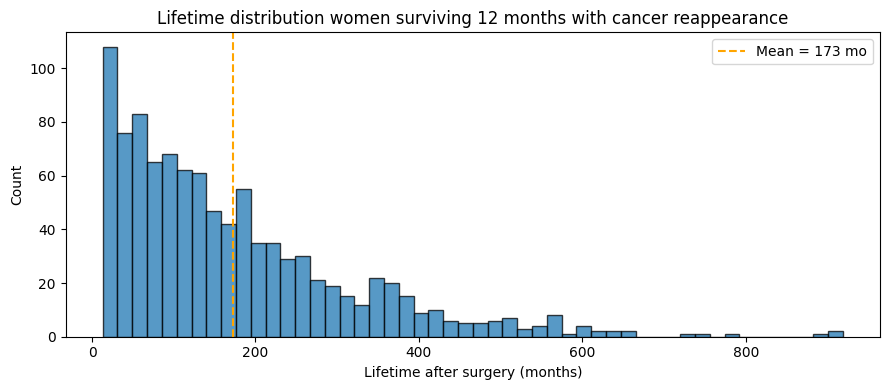

In [179]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(accepted_lifetimes, bins=50, edgecolor='black', alpha=0.75)
ax.axvline(mean_life, color = "orange", linestyle='--', label=f"Mean = {mean_life:.0f} mo")
ax.set_xlabel("Lifetime after surgery (months)")
ax.set_ylabel("Count")
ax.set_title("Lifetime distribution women surviving 12 months with cancer reappearance")
ax.legend()
plt.tight_layout()
plt.show()

## Task 5:

In [183]:
np.random.seed(42)
n_batch = 200
n_reps  = 100
threshold = 350

Ps_cv = P[:4, :4]
ps_cv = P[:4, 4]
pi_cv = np.array([1.0, 0.0, 0.0, 0.0])
mu_C  = float(pi_cv @ np.linalg.inv(np.eye(4) - Ps_cv) @ np.ones(4))  # E[lifetime]

def simulate_batch(n):
    lts = np.zeros(n, dtype=int)
    for i in range(n):
        s, t = 0, 0
        while s != 4:
            s = np.random.choice(5, p=P[s])
            t += 1
        lts[i] = t
    return lts

np.random.seed(42)

Z_crude = np.zeros(n_reps)
C_vals  = np.zeros(n_reps)

for r in range(n_reps):
    lts = simulate_batch(n_batch)
    Z_crude[r] = (lts <= threshold).mean()
    C_vals[r]  = lts.mean()

# Estimate optimal coefficient c
cov_ZC = np.cov(Z_crude, C_vals)[0, 1]
var_C  = np.var(C_vals, ddof=1)
c_opt  = -cov_ZC / var_C

Z_cv = Z_crude + c_opt * (C_vals - mu_C)

var_crude = np.var(Z_crude, ddof=1)
var_cv    = np.var(Z_cv,    ddof=1)
reduction = (1 - var_cv / var_crude) * 100

print(f"Known E[lifetime] (control mean mu_C) = {mu_C:.2f} months")
print(f"Optimal c = {c_opt:.4f}")
print()
print(f"Crude MC estimate:      {Z_crude.mean():.4f}  (var = {var_crude:.6f})")
print(f"Control variate estim.: {Z_cv.mean():.4f}  (var = {var_cv:.6f})")
print(f"Variance reduction:     {reduction:.1f}%")

Known E[lifetime] (control mean mu_C) = 262.37 months
Optimal c = 0.0021

Crude MC estimate:      0.7375  (var = 0.001301)
Control variate estim.: 0.7371  (var = 0.000309)
Variance reduction:     76.2%


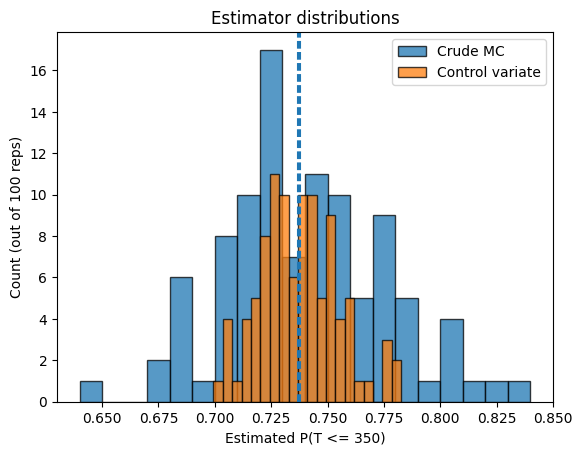

In [184]:
plt.hist(Z_crude, bins=20, edgecolor='black', alpha=0.75, label='Crude MC')
plt.hist(Z_cv,    bins=20, edgecolor='black', alpha=0.75, label='Control variate')
plt.axvline(Z_crude.mean(), linestyle='--')
plt.axvline(Z_cv.mean(),       linestyle='--')
plt.xlabel("Estimated P(T <= 350)")
plt.ylabel("Count (out of 100 reps)")
plt.title("Estimator distributions")
plt.legend()
plt.show()

# Part 2: Continuous-time Markov Chain (CTMC)

## Task 7:

Mean lifetime   = 256.37 months  (21.36 years)
  95% CI        = (244.32,  268.42) months
Std deviation   = 194.38 months
  95% CI (std)  = (185.86,  202.90) months

Proportion with distant cancer at t=30.5 months: 0.0800


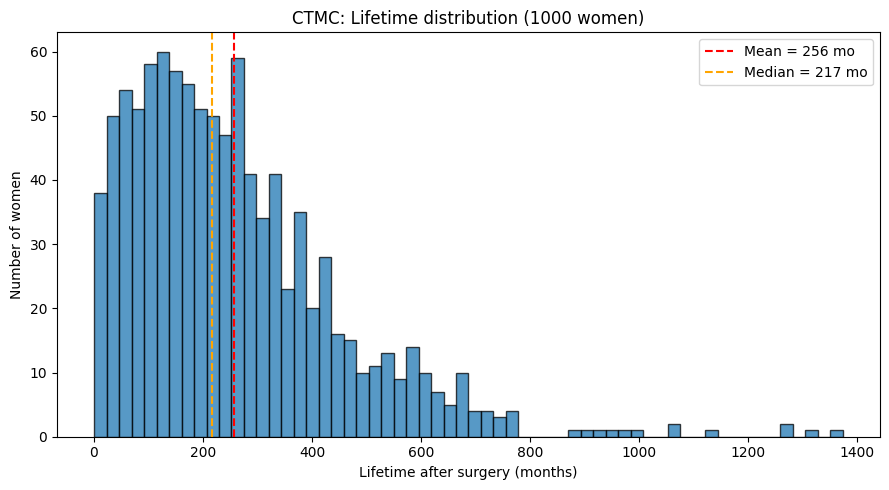

In [ ]:
from scipy.linalg import expm

Q = np.array([
    [-0.0085, 0.005 , 0.0025, 0    , 0.001],
    [ 0     ,-0.014 , 0.005 , 0.004, 0.005],
    [ 0     , 0     ,-0.008 , 0.003, 0.005],
    [ 0     , 0     , 0     ,-0.009, 0.009],
    [ 0     , 0     , 0     , 0    , 0    ]
])

np.random.seed(42)
N = 1000
lifetimes_ct  = np.zeros(N)
state_at_30_5 = np.zeros(N, dtype=int)

for i in range(N):
    state = 0
    t     = 0.0
    past_30_5 = False

    while state != 4:
        rate = -Q[state, state]
        sojourn = np.random.exponential(1.0 / rate)

        if not past_30_5 and t + sojourn >= 30.5:
            state_at_30_5[i] = state
            past_30_5 = True

        t += sojourn

        off_diag_rates = Q[state].copy()
        off_diag_rates[state] = 0.0
        probs = off_diag_rates / off_diag_rates.sum()
        state = np.random.choice(5, p=probs)

    if not past_30_5:
        state_at_30_5[i] = 4
    lifetimes_ct[i] = t

mean_ct = lifetimes_ct.mean()
std_ct  = lifetimes_ct.std(ddof=1)
se_ct   = std_ct / np.sqrt(N)
se_std  = std_ct / np.sqrt(2 * (N - 1))

print(f"Mean lifetime   = {mean_ct:.2f} months  ({mean_ct/12:.2f} years)")
print(f"  95% CI        = ({mean_ct - 1.96*se_ct:.2f},  {mean_ct + 1.96*se_ct:.2f}) months")
print(f"Std deviation   = {std_ct:.2f} months")
print(f"  95% CI (std)  = ({std_ct - 1.96*se_std:.2f},  {std_ct + 1.96*se_std:.2f}) months")

prop_distant = ((state_at_30_5 == 2) | (state_at_30_5 == 3)).mean()
print(f"\nProportion with distant cancer at t=30.5 months: {prop_distant:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(lifetimes_ct, bins=60, edgecolor='black', alpha=0.75)
ax.axvline(mean_ct, color='red',    linestyle='--', label=f"Mean = {mean_ct:.0f} mo")
ax.axvline(np.median(lifetimes_ct),color='orange', linestyle='--',
           label=f"Median = {np.median(lifetimes_ct):.0f} mo")
ax.set_xlabel("Lifetime after surgery (months)")
ax.set_ylabel("Number of women")
ax.set_title("CTMC: Lifetime distribution (1000 women)")
ax.legend()
plt.tight_layout()
plt.show()

## Task 8:

In [ ]:
Qs = Q[:4, :4]
p0_ct = np.array([1.0, 0.0, 0.0, 0.0])
ones4 = np.ones(4)

def F_theoretical(t_arr):
    t_arr = np.atleast_1d(t_arr)
    return np.array([1.0 - p0_ct @ expm(Qs * ti) @ ones4 for ti in t_arr])

ks_stat, ks_p = stats.kstest(lifetimes_ct, F_theoretical)
print(f"Kolmogorov-Smirnov test empirical vs. continuous phase-type CDF")
print(f"KS statistic = {ks_stat:.4f}")
print(f"p-value      = {ks_p:.4f}")
if ks_p > 0.05:
    print("Fail to reject H0: empirical distribution matches theoretical.")
else:
    print("Reject H0 at alpha = 0.05.")

Kolmogorov-Smirnov test empirical vs. continuous phase-type CDF
KS statistic = 0.0239
p-value      = 0.6110
Fail to reject H0: empirical distribution matches theoretical.


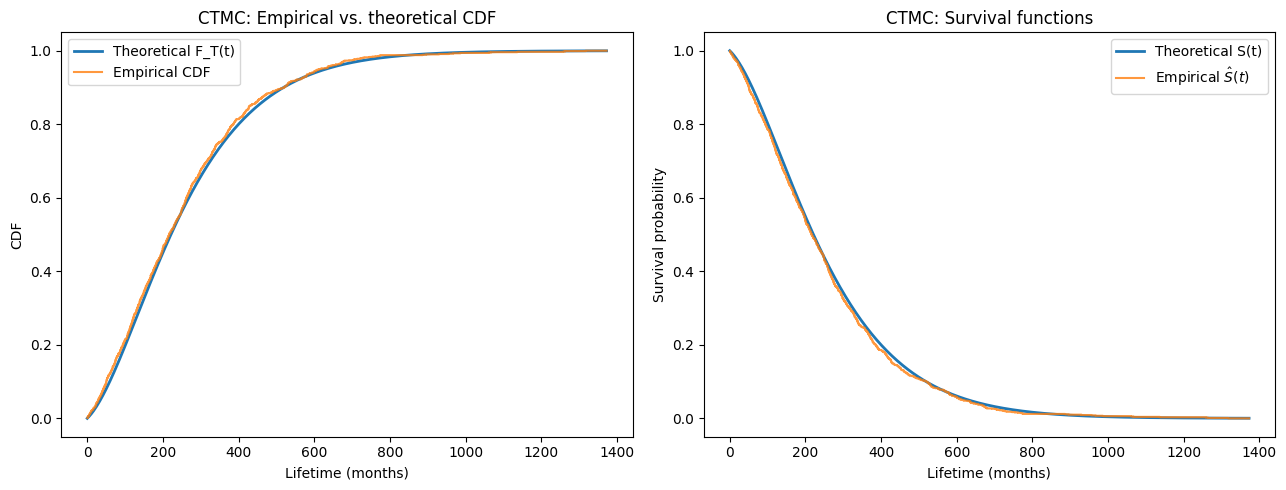

In [ ]:
t_grid = np.linspace(0, lifetimes_ct.max(), 500)
F_theo  = F_theoretical(t_grid)
ecdf_x  = np.sort(lifetimes_ct)
ecdf_y  = np.arange(1, N + 1) / N

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(t_grid, F_theo, lw=2, label='Theoretical F_T(t)')
ax.step(ecdf_x, ecdf_y, lw=1.5, alpha=0.8, label='Empirical CDF')
ax.set_xlabel("Lifetime (months)")
ax.set_ylabel("CDF")
ax.set_title("CTMC: Empirical vs. theoretical CDF")
ax.legend()

ax2 = axes[1]
ax2.plot(t_grid, 1 - F_theo, lw=2, label='Theoretical S(t)')
ax2.step(ecdf_x, 1 - ecdf_y, lw=1.5, alpha=0.8, label='Empirical $\\hat{S}(t)$')
ax2.set_xlabel("Lifetime (months)")
ax2.set_ylabel("Survival probability")
ax2.set_title("CTMC: Survival functions")
ax2.legend()

plt.tight_layout()
plt.show()

## Task 9:

In [195]:
Q_treat_off = np.array([
    [0,       0.0025,  0.00125, 0,      0.001 ],
    [0,       0,       0,       0.002,  0.005 ],
    [0,       0,       0,       0.003,  0.005 ],
    [0,       0,       0,       0,      0.009 ],
    [0,       0,       0,       0,      0     ]
])
Q_treat = Q_treat_off.copy()
for i in range(5):
    Q_treat[i, i] = -Q_treat_off[i].sum()
    
print("Q_treat = \n", Q_treat, "\n")

def simulate_ctmc(Q_mat, n):
    np.random.seed(42)
    lts = np.zeros(n)
    for i in range(n):
        state = 0
        t = 0.0
        while state != 4:
            rate = -Q_mat[state, state]
            t += np.random.exponential(1.0 / rate)
            off = Q_mat[state].copy(); off[state] = 0.0
            state = np.random.choice(5, p=off / off.sum())
        lts[i] = t
    return lts

lts_no_treat = lifetimes_ct
lts_treat    = simulate_ctmc(Q_treat, N)

def kaplan_meier(lifetimes):
    times = np.sort(lifetimes)
    surv  = 1 - np.arange(1, len(times) + 1) / len(times)
    return np.concatenate([[0], times]), np.concatenate([[1], surv])

t_no, S_no = kaplan_meier(lts_no_treat)
t_tr, S_tr = kaplan_meier(lts_treat)

print(f"No treatment: mean = {lts_no_treat.mean():.1f} mo  ({lts_no_treat.mean()/12:.1f} yr)")
print(f"Treatment:    mean = {lts_treat.mean():.1f} mo  ({lts_treat.mean()/12:.1f} yr)")

Q_treat = 
 [[-0.00475  0.0025   0.00125  0.       0.001  ]
 [ 0.      -0.007    0.       0.002    0.005  ]
 [ 0.       0.      -0.008    0.003    0.005  ]
 [ 0.       0.       0.      -0.009    0.009  ]
 [ 0.       0.       0.       0.      -0.     ]] 

No treatment: mean = 256.4 mo  (21.4 yr)
Treatment:    mean = 343.2 mo  (28.6 yr)


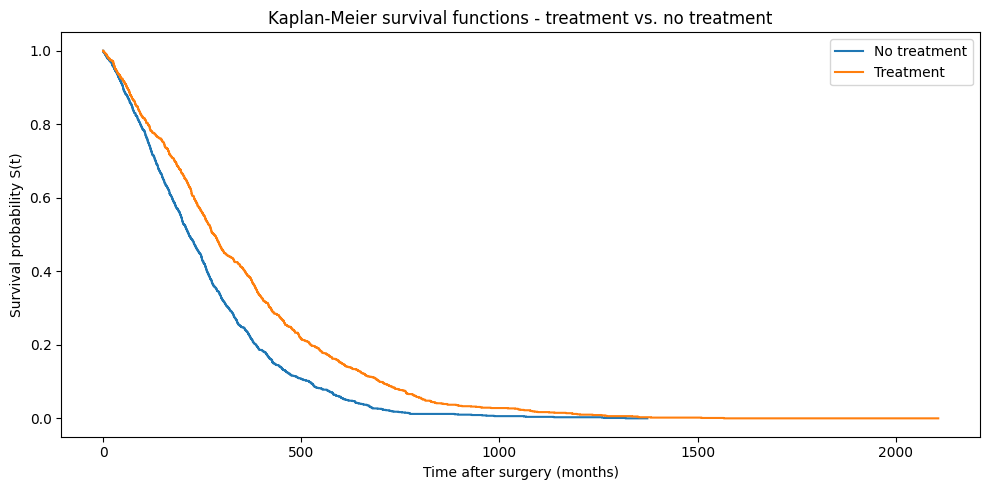

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.step(t_no, S_no, lw=1.5, label="No treatment")
ax.step(t_tr, S_tr, lw=1.5, label="Treatment")
# ax.plot(t_grid, 1 - F_theo, lw=2, label='Theoretical S(t)')
ax.set_xlabel("Time after surgery (months)")
ax.set_ylabel("Survival probability S(t)")
ax.set_title("Kaplan-Meier survival functions - treatment vs. no treatment")
ax.legend()
plt.tight_layout()
plt.show()

## Task 10 (Optional):

In [196]:
all_times = np.sort(np.unique(np.concatenate([lts_no_treat, lts_treat])))
O_untr = np.array([(lts_no_treat == t).sum() for t in all_times])
O_tr = np.array([(lts_treat    == t).sum() for t in all_times])

N_untr = np.array([(lts_no_treat >= t).sum() for t in all_times])
N_tr = np.array([(lts_treat    >= t).sum() for t in all_times])
N  = N_untr + N_tr
O  = O_untr + O_tr

mask = N > 0
E1   =  O[mask]*(N_untr[mask] / N[mask])

Dis = (O_untr[mask] - E1)
V = (((N_untr[mask] * N_tr[mask] * O[mask] * (N[mask] - O[mask])) /
        (N[mask]**2 * (N[mask] - 1).clip(min=1)))).sum()

logrank_stat = (Dis.sum())**2 / V
logrank_p    = stats.chi2.sf(logrank_stat, df=1)

print(f"Log-rank test")
print(f"chi^2 = {logrank_stat:.4f},  p-value = {logrank_p:.4e}")
if logrank_p < 0.05:
    print("Reject H0: survival functions differ significantly.")
else:
    print("Fail to reject H0: no significant difference.")


Log-rank test
chi^2 = 75.0161,  p-value = 4.6690e-18
Reject H0: survival functions differ significantly.


# Part 3: Estimation

## Task 12:

In [187]:
obs_interval = 48

np.random.seed(42)
time_series = []

for _ in range(1000):
    state = 0
    t = 0.0
    obs = [state]
    next_obs_time = obs_interval

    while state != 4:
        rate    = -Q[state, state]
        sojourn = np.random.exponential(1.0 / rate)

        if t + sojourn >= next_obs_time:
            t = next_obs_time
            obs.append(state)
            next_obs_time += obs_interval
        else:
            t += sojourn
            off = Q[state].copy(); off[state] = 0.0
            state = np.random.choice(5, p=off / off.sum())

    if obs[-1] != 4:
        obs.append(4)

    time_series.append(obs)

lengths = [len(ts) for ts in time_series]
print(f"Generated {len(time_series)} time series.")
print(f"Length (# observations): min={min(lengths)}, max={max(lengths)}, mean={np.mean(lengths):.1f}")
print(f"\nExamples of first 5 time series:")
for i in range(5):
    print(f"Woman {i+1}: {time_series[i]}")

Generated 1000 time series.
Length (# observations): min=2, max=25, mean=6.8

Examples of first 5 time series:
Woman 1: [0, 0, 0, 0, 0, 4]
Woman 2: [0, 0, 0, 4]
Woman 3: [0, 0, 2, 2, 4]
Woman 4: [0, 1, 4]
Woman 5: [0, 1, 4]


## Task 13:

In [200]:
def simulate_segment(Q_cur, start_state, end_state, duration, max_tries=50000):
    n_states = Q_cur.shape[0]
    for _ in range(max_tries):
        Nij = np.zeros((n_states, n_states))
        Si  = np.zeros(n_states)
        state = start_state
        t = 0.0

        while True:
            rate = -Q_cur[state, state]
            if rate == 0:
                break
            sojourn = np.random.exponential(1.0 / rate)

            if t + sojourn >= duration:
                Si[state] += duration - t
                break
            else:
                Si[state] += sojourn
                t += sojourn
                off = Q_cur[state].copy(); off[state] = 0.0
                next_s = np.random.choice(n_states, p=off / off.sum())
                Nij[state, next_s] += 1
                state = next_s

        if state == end_state:
            return Nij, Si
    return None

def mcem_update(Q_cur, time_series, obs_interval):
    n_states = Q_cur.shape[0]
    Nij_total = np.zeros((n_states, n_states))
    Si_total  = np.zeros(n_states)

    for ts in time_series:
        for k in range(len(ts) - 1):
            s_start = ts[k]
            s_end   = ts[k + 1]

            if s_start == 4:
                break

            result = simulate_segment(Q_cur, s_start, s_end, obs_interval)
            if result is None:
                continue
            Nij, Si = result
            Nij_total += Nij
            Si_total  += Si

    Q_new = np.zeros_like(Q_cur)
    for i in range(n_states - 1):
        for j in range(n_states):
            if i != j and Si_total[i] > 0:
                Q_new[i, j] = Nij_total[i, j] / Si_total[i]
        Q_new[i, i] = -Q_new[i].sum()

    return Q_new

Q_init = np.array([
    [-0.010, 0.006,  0.003,  0,      0.001 ],
    [ 0,    -0.016,  0.006,  0.005,  0.005 ],
    [ 0,     0,     -0.010,  0.004,  0.006 ],
    [ 0,     0,      0,     -0.012,  0.012 ],
    [ 0,     0,      0,      0,      0     ]
])

np.random.seed(42)
Q_cur  = Q_init.copy()
tol    = 1e-3
max_iter = 30
history = [Q_cur.copy()]

for iteration in range(max_iter):
    Q_new = mcem_update(Q_cur, time_series, obs_interval)
    diff  = np.max(np.abs(Q_new - Q_cur))
    Q_cur = Q_new
    history.append(Q_cur.copy())
    print(f"Iter {iteration+1:2d}: diff = {diff:.6f}")
    print(Q_cur)
    if diff < tol:
        print("Converged.")
        break

print(f"\nTrue Q:\n{Q}")
print(f"\nEstimated Q:\n{Q_cur.round(5)}")

Iter  1: diff = 0.002455
[[-0.00865609  0.00509844  0.00247564  0.          0.00108201]
 [ 0.         -0.01354483  0.00515117  0.00411634  0.00427731]
 [ 0.          0.         -0.00830227  0.00341858  0.00488369]
 [ 0.          0.          0.         -0.01128486  0.01128486]
 [ 0.          0.          0.          0.          0.        ]]
Iter  2: diff = 0.000598
[[-0.00865203  0.00515661  0.00244852  0.          0.0010469 ]
 [ 0.         -0.01353993  0.0050434   0.00402109  0.00447545]
 [ 0.          0.         -0.00824472  0.00321626  0.00502846]
 [ 0.          0.          0.         -0.01068677  0.01068677]
 [ 0.          0.          0.          0.          0.        ]]
Converged.

True Q:
[[-0.0085  0.005   0.0025  0.      0.001 ]
 [ 0.     -0.014   0.005   0.004   0.005 ]
 [ 0.      0.     -0.008   0.003   0.005 ]
 [ 0.      0.      0.     -0.009   0.009 ]
 [ 0.      0.      0.      0.      0.    ]]

Estimated Q:
[[-0.00865  0.00516  0.00245  0.       0.00105]
 [ 0.      -0.01354 